In [1]:
from src.roi_classifier import ROIClassifier

In [31]:
LOAD_KWARGS = {
    'iof_path': "e:/products/1480/iof",
    'seq_id': None,
    'obs_ix': 1,
    'do_apply_pixmaps': True,
    'ignore_bayers': False,
}
PREPROCESS_KWARGS = {
    'SHADDOW_KWARGS': {
        'percentiles': (6, 99),
        'operator': 'and'
    },
    "SKYMASK_KWARGS": {
        'percentile': 75,
        'edge_params': {"maximum": 5, "erosion": 3},
        'input_median': 5,
        'trace_maximum': 5,
        'cutoffs': {
            "extent": 0.05, "coverage": None, "v": 0.9, "h": None
        },
        'input_mask_dilation': None,
        'input_stretch': (10, 1),
        'floodfill': True,
        'trim_params': {"trim": False},
        'clear': True,
        'colorblock': False,
        'respect_mask': False,
    },
    'DO_APPLY_R_STAR': True
}
ROI_KWARGS = {
    'edge_offset': 10,
    'allowed_variance': 4  # maximum degree of variance in SAM segment mask
}
ROI_AREA_THRESHOLD = 50

SAM_MODEL_PATH = "C:\\Users\\Lars\\Documents\\Python\\mars_lab\\models\\sam_vit_h_4b8939.pth"


In [32]:
Classifier = ROIClassifier()
Classifier.load(LOAD_KWARGS)

In [33]:
Classifier.preprocess(**PREPROCESS_KWARGS)

In [34]:
Classifier.processed_data.shape

(14, 1178, 1598)

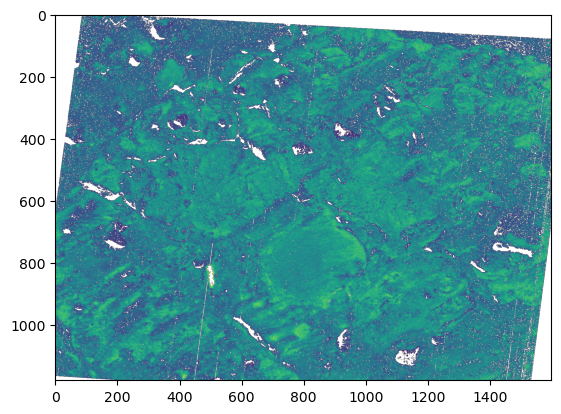

In [35]:
import matplotlib.pyplot as plt

plt.imshow(Classifier.processed_data[3])
plt.show()

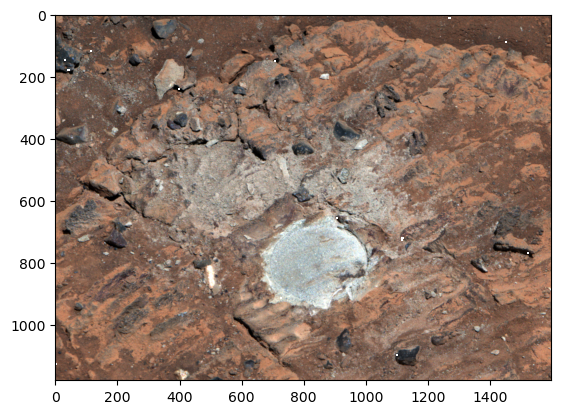

In [36]:
img = Classifier.load_result['rgb_img']
plt.imshow(img)
plt.show()

In [37]:
Classifier.compute_potential_rois(SAM_MODEL_PATH, ROI_KWARGS)

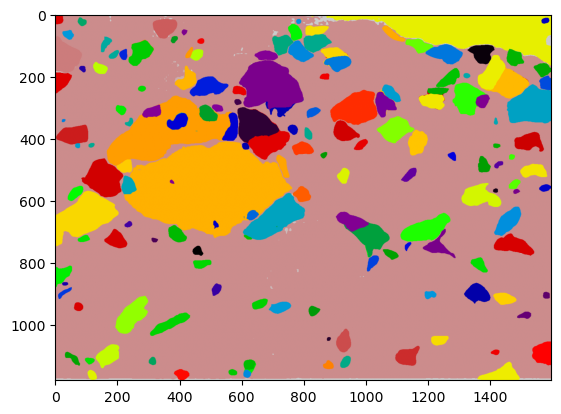

In [38]:
# validate that image segmented properly
mask = Classifier.segments
plt.imshow(mask, cmap="nipy_spectral_r")
plt.show()

In [39]:
Classifier.filter_roi(ROI_AREA_THRESHOLD)

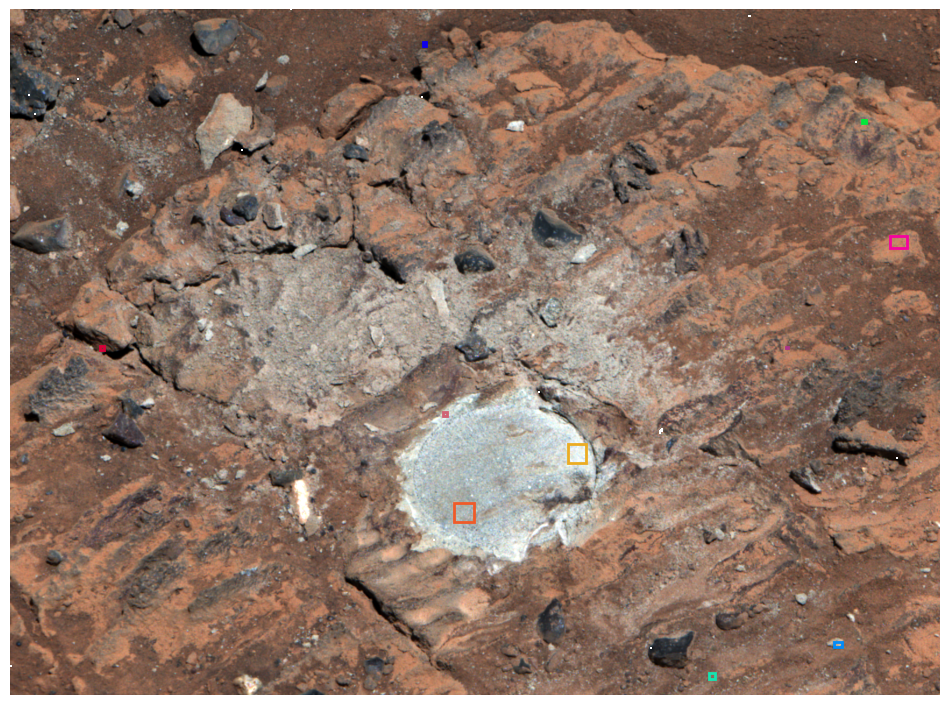

In [40]:
Classifier.show_rois()

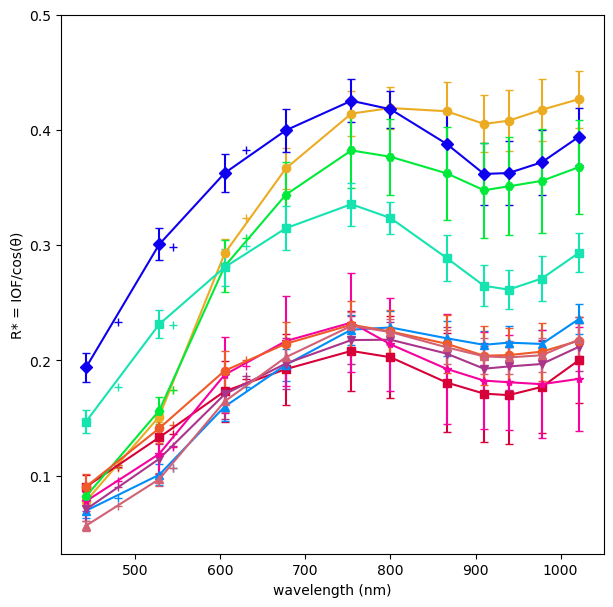

In [41]:
Classifier.show_spectra()

In [118]:
from marslab.compat.sel_to_roi import sel_to_roi
from pathlib import Path

fs = sel_to_roi(Path("e:/products/1480/Z01480_0730000ZCAM04124_110082691_FN1.sel"), 'ZCAM')

In [119]:
from marslab.imgops.regions import make_roi_edgemaps, draw_edgemaps_on_axis

maps = make_roi_edgemaps(fs)

In [101]:
spdl_r_masks = {k: v for k, v in maps.items() if k.endswith("right")}

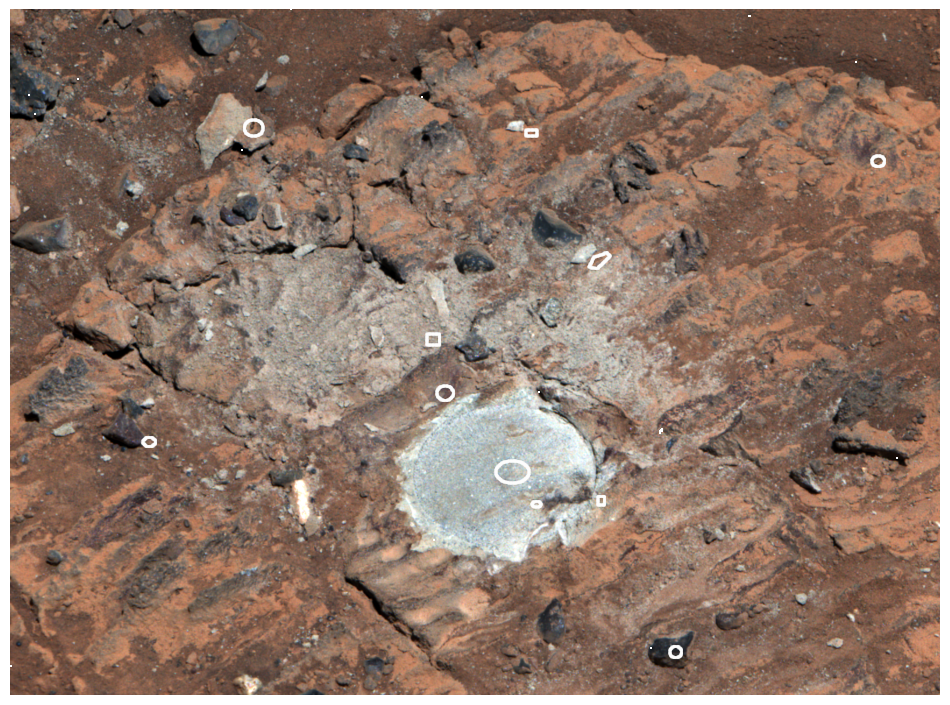

In [102]:
fig, ax = plt.subplots(figsize=(12, 9))
fig.frameon = False
ax.set_axis_off()

ax.imshow(img)

draw_edgemaps_on_axis(ax, spdl_r_masks)